In [3]:
import pandas as pd

In [6]:
df = pd.read_csv("cases.csv")

In [32]:
df["status"].value_counts()

,count
status,
Closed,201
Open,99


In [31]:
df.head()

,case_id,client_name,attorney,insurance_company,damage_type,status,open_date,close_date,estimated_damage,settlement_amount,case_duration
0,C001,Matthew Wilson,Emily Johnson,Heritage,Hurricane,Open,2025-04-25,NaT,21024,0,NaT
1,C002,John Carter,Sarah Mitchell,State Farm,Water,Open,2026-07-13,NaT,30651,0,NaT
2,C003,Charlotte White,Michael Davis,Tower Hill,Mold,Closed,2026-06-02,2026-08-31,49925,18031,90 days
3,C004,Sophia Anderson,Daniel Wilson,State Farm,Water,Closed,2025-10-12,2025-10-28,48753,15463,16 days
4,C005,David Thomas,Olivia Brown,Universal,Roof,Open,2025-12-11,NaT,27898,0,NaT


In [7]:
df.shape

(300, 10)

In [8]:
df.columns

Index(['case_id', 'client_name', 'attorney', 'insurance_company',
       'damage_type', 'status', 'open_date', 'close_date', 'estimated_damage',
       'settlement_amount'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   case_id            300 non-null    object
 1   client_name        300 non-null    object
 2   attorney           300 non-null    object
 3   insurance_company  300 non-null    object
 4   damage_type        300 non-null    object
 5   status             300 non-null    object
 6   open_date          300 non-null    object
 7   close_date         201 non-null    object
 8   estimated_damage   300 non-null    int64 
 9   settlement_amount  300 non-null    int64 
dtypes: int64(2), object(8)
memory usage: 23.6+ KB


In [10]:
df.isna().sum()

,0
case_id,0
client_name,0
attorney,0
insurance_company,0
damage_type,0
status,0
open_date,0
close_date,99
estimated_damage,0
settlement_amount,0


In [11]:
df["open_date"] = pd.to_datetime(
    df["open_date"],
    errors="coerce"
)

In [12]:
df["close_date"] = pd.to_datetime( df["close_date"], errors="coerce" )

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   case_id            300 non-null    object        
 1   client_name        300 non-null    object        
 2   attorney           300 non-null    object        
 3   insurance_company  300 non-null    object        
 4   damage_type        300 non-null    object        
 5   status             300 non-null    object        
 6   open_date          300 non-null    datetime64[ns]
 7   close_date         201 non-null    datetime64[ns]
 8   estimated_damage   300 non-null    int64         
 9   settlement_amount  300 non-null    int64         
dtypes: datetime64[ns](2), int64(2), object(6)
memory usage: 23.6+ KB


In [14]:
df["status"].value_counts()

,count
status,
Closed,201
Open,99


In [15]:
df["damage_type"].value_counts()

,count
damage_type,
Fire,67
Roof,66
Water,57
Mold,56
Hurricane,54


In [16]:
df["insurance_company"].value_counts()

,count
insurance_company,
Heritage,56
State Farm,52
Citizens,52
Universal,50
Liberty Mutual,48
Tower Hill,42


In [17]:
df["estimated_damage"].mean()

np.float64(26871.42)

In [18]:
df["settlement_amount"].mean()

np.float64(17177.6)

In [19]:
closed_cases = df[df["status"] == "Closed"]

In [20]:
closed_cases["settlement_amount"].mean()

np.float64(25638.20895522388)

In [21]:
df["close_date"] - df["open_date"]

,0
0,NaT
1,NaT
2,90 days
3,16 days
4,NaT
...,...
295,NaT
296,NaT
297,49 days
298,167 days


In [22]:
df["case_duration"] = df["close_date"] - df["open_date"]

In [23]:
df.head()

,case_id,client_name,attorney,insurance_company,damage_type,status,open_date,close_date,estimated_damage,settlement_amount,case_duration
0,C001,Matthew Wilson,Emily Johnson,Heritage,Hurricane,Open,2025-04-25,NaT,21024,0,NaT
1,C002,John Carter,Sarah Mitchell,State Farm,Water,Open,2026-07-13,NaT,30651,0,NaT
2,C003,Charlotte White,Michael Davis,Tower Hill,Mold,Closed,2026-06-02,2026-08-31,49925,18031,90 days
3,C004,Sophia Anderson,Daniel Wilson,State Farm,Water,Closed,2025-10-12,2025-10-28,48753,15463,16 days
4,C005,David Thomas,Olivia Brown,Universal,Roof,Open,2025-12-11,NaT,27898,0,NaT


In [25]:
closed_cases = df[df["status"] == "Closed"]

In [26]:
closed_cases["case_duration"].mean()

Timedelta('92 days 18:51:56.417910448')

In [27]:
closed_cases["case_duration"].dt.days

,case_duration
2,90
3,16
5,152
6,32
8,180
...,...
293,38
294,158
297,49
298,167


In [28]:
closed_cases["case_duration"].dt.days.mean()

np.float64(92.7860696517413)

In [29]:
df.groupby("damage_type")["estimated_damage"].mean()

,estimated_damage
damage_type,
Fire,25539.805970
Hurricane,28917.481481
Mold,26179.964286
Roof,29110.818182
Water,24584.614035


<Axes: xlabel='damage_type'>

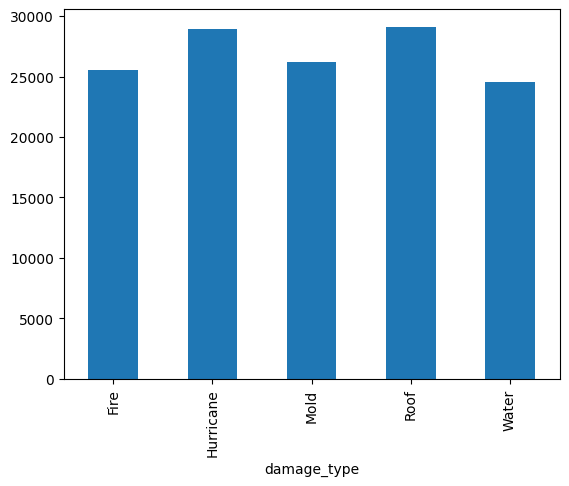

In [30]:
df.groupby("damage_type")["estimated_damage"].mean().plot(kind="bar")

<Axes: xlabel='status'>

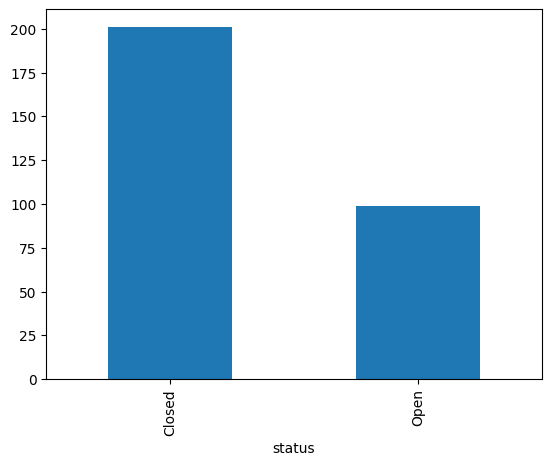

In [33]:
df["status"].value_counts().plot(kind="bar")